In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import pi

# =====================================================
# Utility functions (used in Q1 and Q2)
# =====================================================

def mse(x, y):
    """Mean Squared Error between two equal-length signals."""
    x = np.asarray(x)
    y = np.asarray(y)
    n = min(len(x), len(y))
    return float(np.mean((x[:n] - y[:n])**2))

def normalize(sig):
    """Peak-normalize a signal to [-1, 1] range (avoid divide-by-zero)."""
    m = np.max(np.abs(sig)) + 1e-12
    return sig / m

def resample_by_indexing(x, fs_in, fs_out):
    """
    Deterministic resampling using time-index mapping (no external libs).
    Creates a new array x_out at rate fs_out, derived from x at fs_in.
    Uses linear interpolation internally (for clean down/up sampling here).
    """
    if fs_in == fs_out:
        return x.copy()
    duration = len(x) / fs_in
    t_out = np.arange(0, duration, 1.0/fs_out)
    t_in = np.arange(len(x)) / fs_in
    # Linear interpolation
    idx = np.searchsorted(t_in, t_out, side='left')
    idx0 = np.clip(idx - 1, 0, len(x)-1)
    idx1 = np.clip(idx,     0, len(x)-1)
    t0 = t_in[idx0]
    t1 = t_in[idx1]
    denom = (t1 - t0)
    denom[denom == 0] = 1.0  # avoid division by zero when t1==t0
    w = (t_out - t0) / denom
    return (1.0 - w) * x[idx0] + w * x[idx1]

def zero_order_hold_upsample(x, fs_in, fs_out):
    """
    Zero-Order Hold (nearest-neighbor) upsample from fs_in to fs_out.
    If fs_out < fs_in, this does simple decimation by nearest index.
    """
    duration = len(x) / fs_in
    t_out = np.arange(0, duration, 1.0/fs_out)
    t_in  = np.arange(len(x)) / fs_in
    # Nearest neighbor: pick closest input index for each output time
    idx = np.searchsorted(t_in, t_out)
    idx = np.clip(idx, 0, len(x)-1)
    # Check whether previous index is closer
    idx_prev = np.clip(idx - 1, 0, len(x)-1)
    choose_prev = np.abs(t_out - t_in[idx_prev]) < np.abs(t_out - t_in[idx])
    idx = np.where(choose_prev, idx_prev, idx)
    return x[idx]

def linear_interpolate_upsample(x, fs_in, fs_out):
    """Linear interpolation upsample from fs_in to fs_out."""
    return resample_by_indexing(x, fs_in, fs_out)

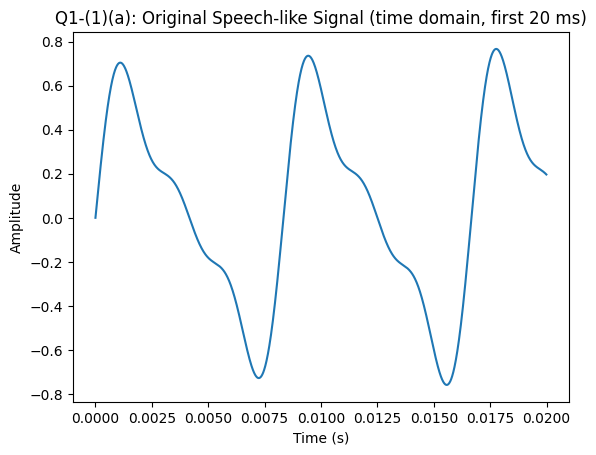

In [6]:
# Q1. Sampling and Reconstruction (using a synthetic "original" speech-like signal)
# =====================================================
# Q1. Aim: study sampling & reconstruction at different sampling rates, evaluate ZOH vs Linear, compute MSE

# ---- [Q1-(1)(a)] Plot the time domain representation of the original speech signal ----
master_fs = 96000  # High "ground-truth" sampling rate for reference
duration_s = 1.0   # 1 second
t = np.arange(int(master_fs * duration_s)) / master_fs

# Create a speech-like waveform: sum of low harmonics with slight amplitude modulation
f0 = 120.0  # base pitch (Hz)
signal = (0.6*np.sin(2*pi*f0*t) +
          0.3*np.sin(2*pi*2*f0*t) +
          0.15*np.sin(2*pi*3*f0*t))
signal *= (0.7 + 0.3*np.sin(2*pi*2.0*t))  # mild AM to mimic prosody
signal = normalize(signal)

plt.figure()
plt.title("Q1-(1)(a): Original Speech-like Signal (time domain, first 20 ms)")
plt.plot(t[:int(master_fs*0.02)], signal[:int(master_fs*0.02)])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


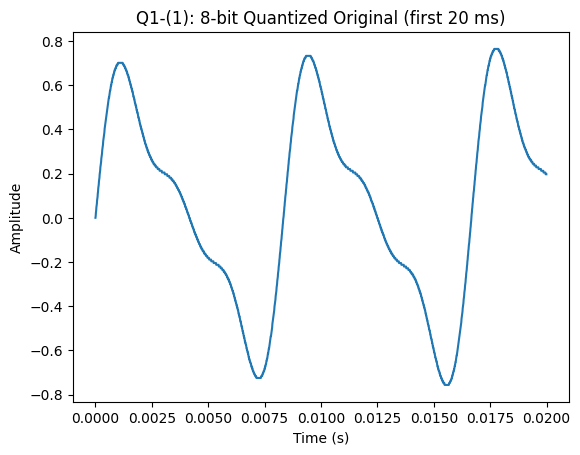

In [7]:
# ---- Q1-(1): Simple quantization demonstration (uniform PCM) ----
def uniform_quantize(x, bits=8):
    """Uniform mid-tread quantizer mapping [-1,1] to 2^bits levels."""
    L = 2**bits
    x_clip = np.clip(x, -1, 1 - 1e-12)
    q = np.round((x_clip + 1.0) * (L/2 - 1)) - (L/2 - 1)
    q = q / (L/2 - 1)
    return q

quantized_8bit = uniform_quantize(signal, bits=8)

plt.figure()
plt.title("Q1-(1): 8-bit Quantized Original (first 20 ms)")
plt.plot(t[:int(master_fs*0.02)], quantized_8bit[:int(master_fs*0.02)])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

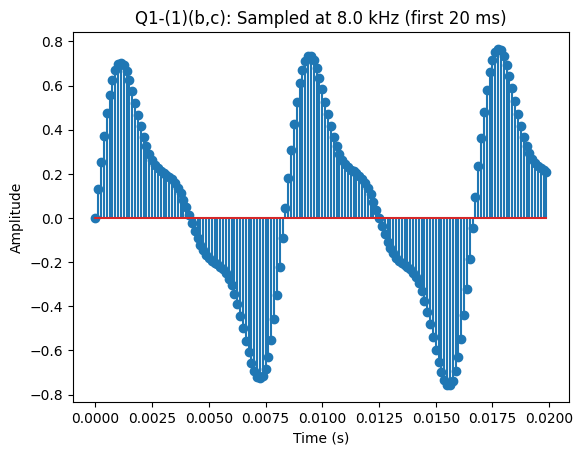

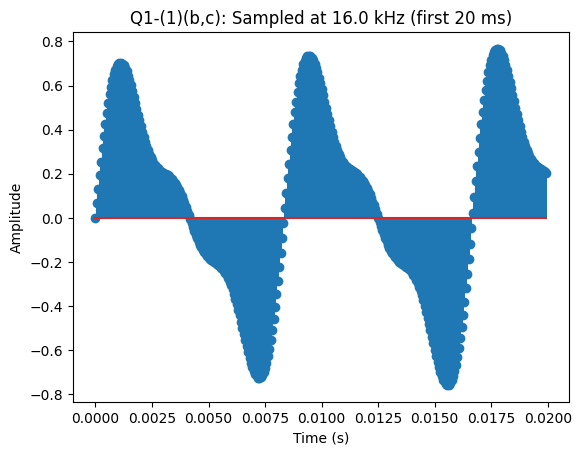

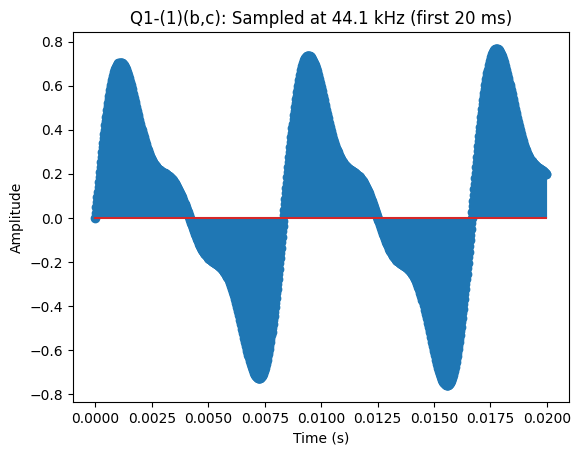

In [10]:
# ---- Q1-(1)(b,c): Sample at different rates and plot ----
sample_rates = [8000, 16000, 44100]
sampled_dict = {}

for fs in sample_rates:
    # Downsample by interpolation (emulate sampling cleanly)
    x_s = resample_by_indexing(signal, master_fs, fs)
    sampled_dict[fs] = x_s

    # Plot a short window for visualization
    tw = np.arange(len(x_s)) / fs
    plt.figure()
    plt.title(f"Q1-(1)(b,c): Sampled at {fs/1000:.1f} kHz (first 20 ms)")
    nwin = int(fs * 0.02)
    plt.stem(tw[:nwin], x_s[:nwin])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

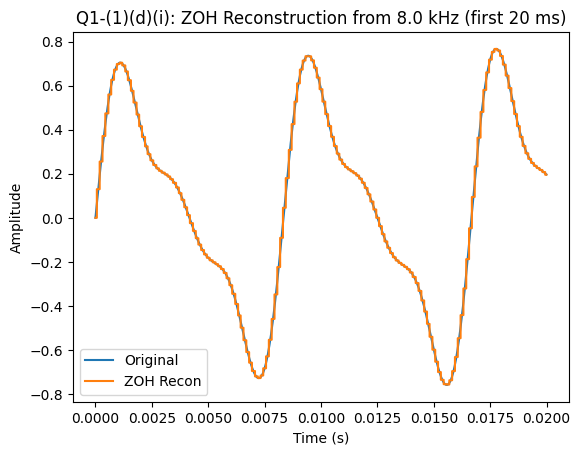

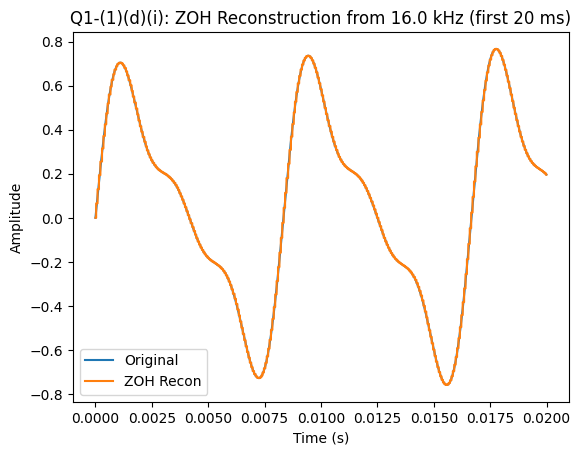

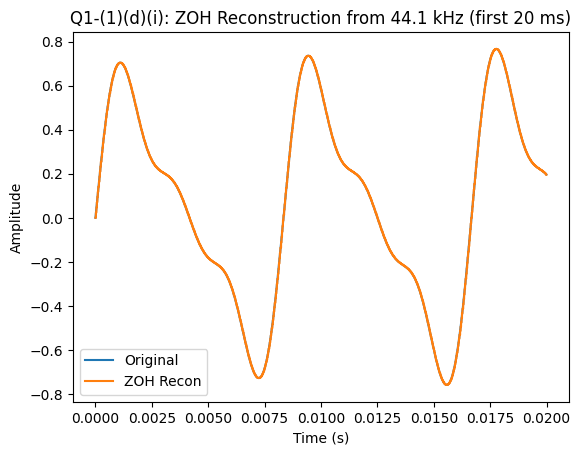

In [21]:
# ---- Q1-(1)(d): Reconstruct back to master_fs using (i) ZOH and (ii) Linear ----
recon_zoh = {}
recon_lin = {}

for fs in sample_rates:
    x_s = sampled_dict[fs]
    # (i) Zero-order hold reconstruction: upsample to master_fs
    recon_zoh[fs] = zero_order_hold_upsample(x_s, fs, master_fs)
    # (ii) Linear interpolation reconstruction: upsample to master_fs
    recon_lin[fs] = linear_interpolate_upsample(x_s, fs, master_fs)

    # Plot a short window to visualize reconstructions
    Nw = int(master_fs * 0.02)
    tw = np.arange(Nw) / master_fs

    plt.figure()
    plt.title(f"Q1-(1)(d)(i): ZOH Reconstruction from {fs/1000:.1f} kHz (first 20 ms)")
    plt.plot(t[:Nw], signal[:Nw], label="Original")
    plt.step(tw, recon_zoh[fs][:Nw], where='post', label="ZOH Recon")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

In [12]:
# ---- Q1-(1)(e): Compute MSE between original and reconstructed signals ----
rows = []
for fs in sample_rates:
    err_zoh = mse(signal, recon_zoh[fs])
    err_lin = mse(signal, recon_lin[fs])
    rows.append({"Sampling Rate (Hz)": fs, "MSE (ZOH)": err_zoh, "MSE (Linear)": err_lin})

df_q1 = pd.DataFrame(rows).sort_values("Sampling Rate (Hz)")
print("\n=== Q1 MSE Results ===")
print(df_q1.to_string(index=False))


=== Q1 MSE Results ===
 Sampling Rate (Hz)  MSE (ZOH)  MSE (Linear)
               8000   0.000268  1.530849e-06
              16000   0.000070  1.250313e-07
              44100   0.000009  3.154190e-09


Q2

In [13]:
# =====================================================
# Q2. Source–Filter Model: build synthetic speech, then sample & reconstruct
# =====================================================

# ---- Q2-(a): Generate a source signal and apply a vocal-tract filter ----
def impulse_train(fs, f0, duration):
    """Generate an impulse train with period = fs/f0 (unit impulses)."""
    n = int(fs*duration)
    out = np.zeros(n)
    period = max(1, int(round(fs / f0)))
    out[::period] = 1.0
    return out

def resonator_biquad_coeffs(f, fs, r=0.98):
    """
    Return (b, a) for a simple 2nd-order resonator centered at frequency f (Hz),
    radius r (0<r<1). Transfer: H(z) = 1 / (1 - 2 r cos(2πf/fs) z^-1 + r^2 z^-2)
    """
    omega = 2.0 * pi * f / fs
    a1 = -2.0 * r * np.cos(omega)
    a2 = r**2
    b = np.array([1.0, 0.0, 0.0])  # numerator
    a = np.array([1.0, a1, a2])    # denominator
    return b, a

def biquad_filter(b, a, x):
    """Direct form IIR filter for 2nd-order section (no SciPy needed)."""
    y = np.zeros_like(x)
    # a[0] assumed 1
    for n in range(len(x)):
        x_n = x[n]
        y_n = b[0]*x_n
        if n-1 >= 0:
            y_n += b[1]*x[n-1] - a[1]*y[n-1]
        if n-2 >= 0:
            y_n += b[2]*x[n-2] - a[2]*y[n-2]
        y[n] = y_n
    return y

def vocal_tract_filter(x, fs, formants=((700, 0.98), (1200, 0.985), (2500, 0.99))):
    """
    Cascade of 2nd-order resonators approximating vocal tract formants.
    formants: list of (frequency_Hz, radius_r) pairs.
    """
    y = x.copy()
    for f, r in formants:
        b, a = resonator_biquad_coeffs(f, fs, r=r)
        y = biquad_filter(b, a, y)
    return y

# Build the source: voiced + unvoiced segments
q2_fs = master_fs  # Work at high rate first
q2_duration = 1.0

In [14]:
# Q2-(a)(i): Source signal
T_voiced = 0.6
T_unvoiced = q2_duration - T_voiced
src_voiced = impulse_train(q2_fs, f0=120.0, duration=T_voiced)  # glottal pulse train (idealized)
src_unvoiced = np.random.randn(int(q2_fs*T_unvoiced)) * 0.1     # white noise (unvoiced)
src = np.concatenate([src_voiced, src_unvoiced])

# Q2-(a)(ii): Apply vocal-tract filter (3 formants as an example vowel-like color)
q2_filtered = vocal_tract_filter(src, q2_fs, formants=((700, 0.98), (1200, 0.985), (2500, 0.99)))
q2_filtered = normalize(q2_filtered)



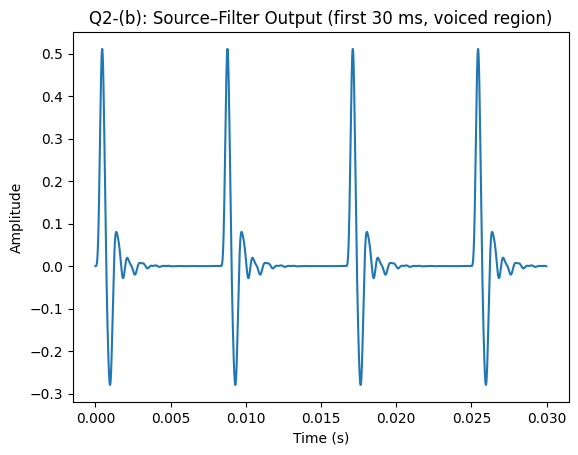

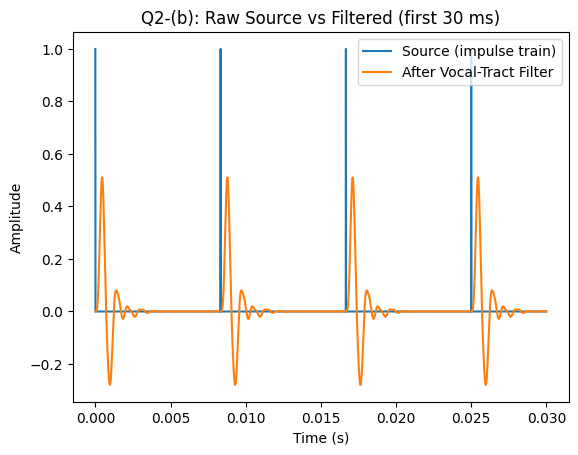

In [15]:
# ---- Q2-(b): Plot the generated speech and show filter effect ----
tt = np.arange(len(q2_filtered)) / q2_fs

plt.figure()
plt.title("Q2-(b): Source–Filter Output (first 30 ms, voiced region)")
plt.plot(tt[:int(q2_fs*0.03)], q2_filtered[:int(q2_fs*0.03)])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.title("Q2-(b): Raw Source vs Filtered (first 30 ms)")
plt.plot(tt[:int(q2_fs*0.03)], src[:int(q2_fs*0.03)], label="Source (impulse train)")
plt.plot(tt[:int(q2_fs*0.03)], q2_filtered[:int(q2_fs*0.03)], label="After Vocal-Tract Filter")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

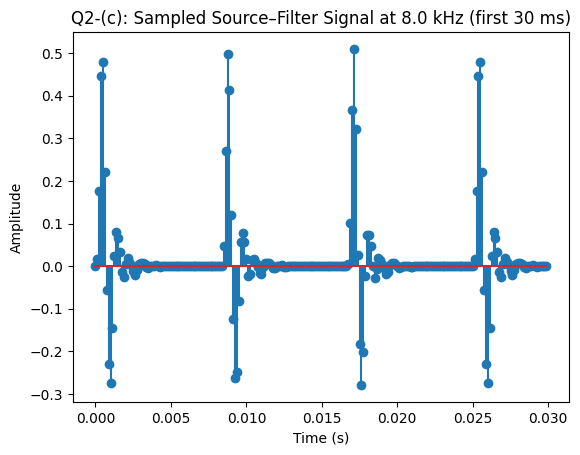

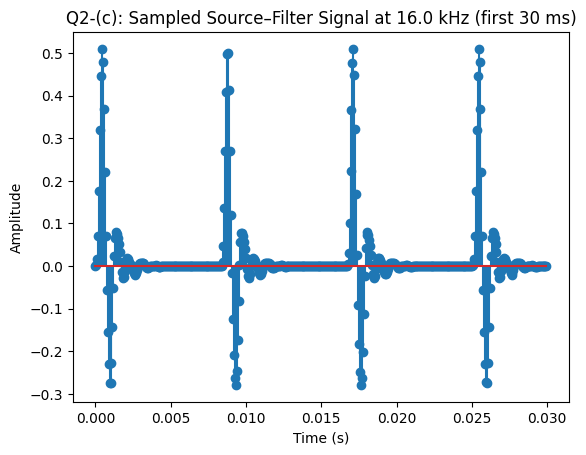

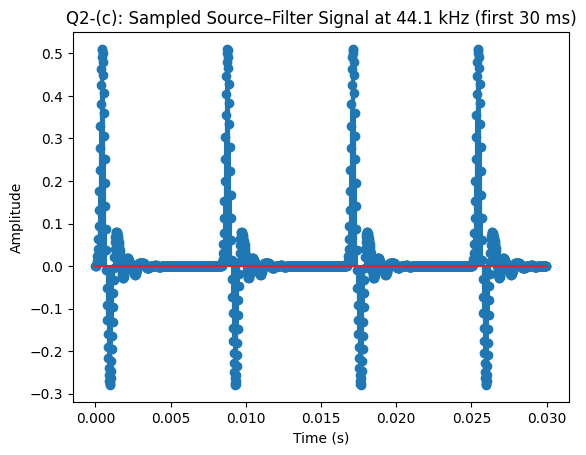

In [17]:
# ---- Q2-(c): Sample at 8k, 16k, 44.1k ----
q2_sample_rates = [8000, 16000, 44100]
q2_sampled = {fs: resample_by_indexing(q2_filtered, q2_fs, fs) for fs in q2_sample_rates}

for fs in q2_sample_rates:
    tw = np.arange(len(q2_sampled[fs])) / fs
    plt.figure()
    plt.title(f"Q2-(c): Sampled Source–Filter Signal at {fs/1000:.1f} kHz (first 30 ms)")
    nwin = int(fs * 0.03)
    plt.stem(tw[:nwin], q2_sampled[fs][:nwin])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

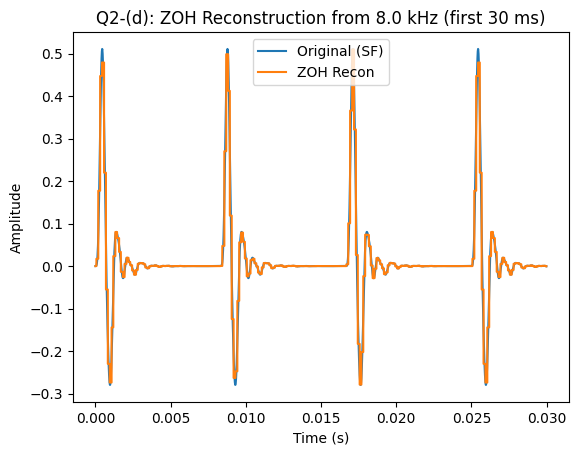

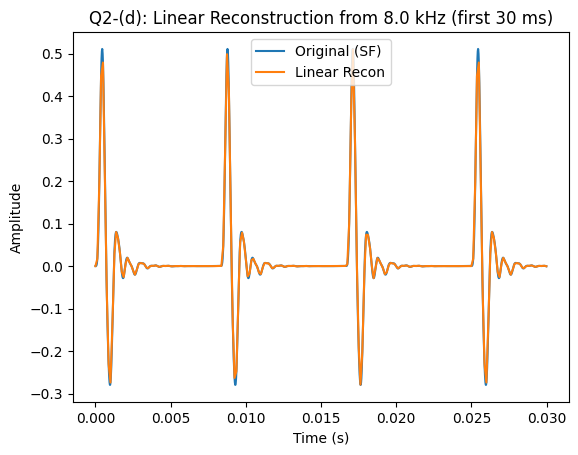

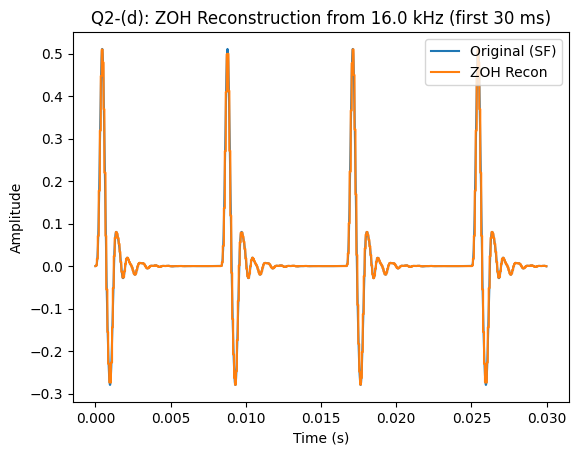

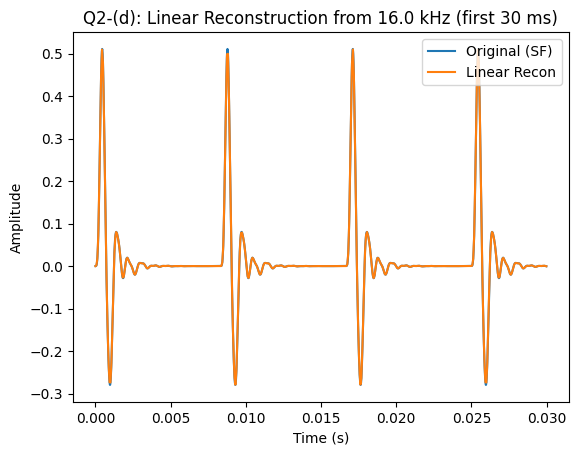

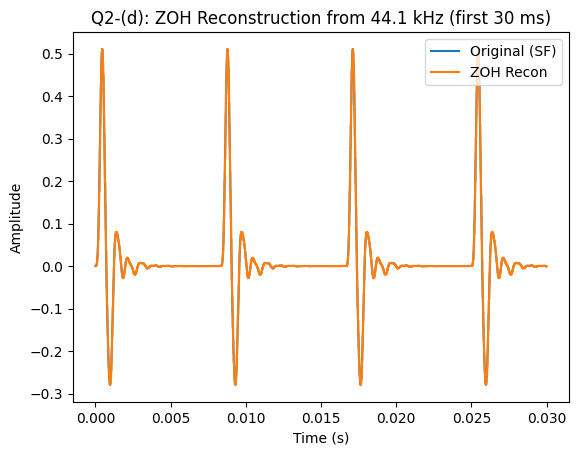

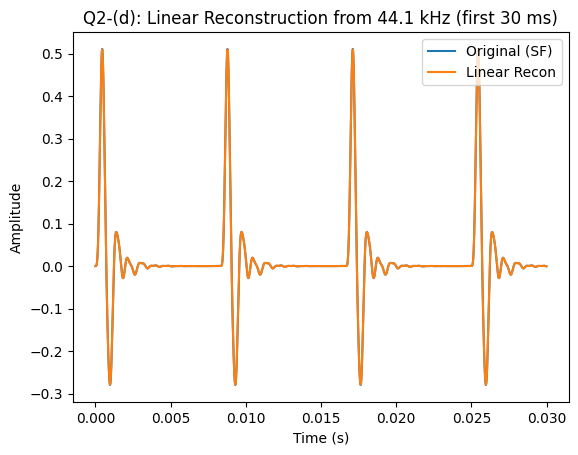

In [18]:
# ---- Q2-(d): Reconstruct using ZOH and Linear back to the original high rate ----
q2_recon_zoh = {}
q2_recon_lin = {}
for fs in q2_sample_rates:
    q2_recon_zoh[fs] = zero_order_hold_upsample(q2_sampled[fs], fs, q2_fs)
    q2_recon_lin[fs] = linear_interpolate_upsample(q2_sampled[fs], fs, q2_fs)

    Nw = int(q2_fs * 0.03)
    tw = np.arange(Nw) / q2_fs

    plt.figure()
    plt.title(f"Q2-(d): ZOH Reconstruction from {fs/1000:.1f} kHz (first 30 ms)")
    plt.plot(tw, q2_filtered[:Nw], label="Original (SF)")
    plt.step(tw, q2_recon_zoh[fs][:Nw], where='post', label="ZOH Recon")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

    plt.figure()
    plt.title(f"Q2-(d): Linear Reconstruction from {fs/1000:.1f} kHz (first 30 ms)")
    plt.plot(tw, q2_filtered[:Nw], label="Original (SF)")
    plt.plot(tw, q2_recon_lin[fs][:Nw], label="Linear Recon")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

In [19]:
# ---- Q2-(e): Compute MSE between original (source–filter) and reconstructions ----
rows_q2 = []
for fs in q2_sample_rates:
    err_zoh = mse(q2_filtered, q2_recon_zoh[fs])
    err_lin = mse(q2_filtered, q2_recon_lin[fs])
    rows_q2.append({"Sampling Rate (Hz)": fs, "MSE (ZOH)": err_zoh, "MSE (Linear)": err_lin})

df_q2 = pd.DataFrame(rows_q2).sort_values("Sampling Rate (Hz)")
print("\n=== Q2 MSE Results (Source–Filter) ===")
print(df_q2.to_string(index=False))


=== Q2 MSE Results (Source–Filter) ===
 Sampling Rate (Hz)  MSE (ZOH)  MSE (Linear)
               8000   0.001753  1.515685e-04
              16000   0.000460  9.947450e-06
              44100   0.000057  2.462747e-07
